In [1]:
import re
import pandas as pd
from time import sleep
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options as Options
from selenium.webdriver.common.keys import Keys
import bs4
import urllib
from bs4 import BeautifulSoup as bs
from urllib.request import urlopen
import time

In [ ]:
# Définition des options Chrome
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36")
chrome_options.add_argument("--disable-blink-features=AutomationControlled")
chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
chrome_options.add_experimental_option("useAutomationExtension", False)

# Initialisation du driver
driver = webdriver.Chrome(options=chrome_options)
driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})") # Masquer Selenium

# Ouvrir Google
url = "https://www.google.fr/"
driver.get(url)
time.sleep(3) # Pause pour éviter la détection

# Accepter/refuser les cookies si le bouton existe
try:
  bouton_cookie = WebDriverWait(driver, 5).until(
    EC.presence_of_element_located((By.XPATH, '//*[@id="W0wltc"]/div'))
  )
  bouton_cookie.click()
  time.sleep(2)

except:
  print("Pas de bouton cookies détecté.")

# Entrer la recherche
recherche = "Doctolib"
search_box = driver.find_element(By.XPATH, '//*[@id="APjFqb"]')
search_box.send_keys(recherche)
time.sleep(2)
search_box.send_keys(Keys.RETURN)

# Attendre que la page se charge
time.sleep(3)



# cliquer sur le premier résultat
try:
    premier_lien = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.XPATH, '(//h3[contains(@class,"LC20lb")])[1]'))
    )
    premier_lien.click()
    time.sleep(2)
except:
    print("Impossible de cliquer sur le lien")

# Accepter/refuser les cookies Doctolib
try:
    bouton_cookie_doctolib = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.ID, "didomi-notice-agree-button"))
    )
    bouton_cookie_doctolib.click()
    time.sleep(2)
except:
    print("Pas de bouton cookies Doctolib détecté.")

#Recherche des pneumologues à Paris :
try:
    # la spécialité
    barre_specialite = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.CLASS_NAME, "searchbar-query-input"))
    )
    barre_specialite.click()
    barre_specialite.send_keys("Pédiatre")
    time.sleep(2)

    # la ville
    barre_ville = driver.find_element(By.CLASS_NAME, "searchbar-place-input")
    barre_ville.click()
    barre_ville.send_keys("île de france")
    time.sleep(2)

    # recherche
    bouton_recherche = driver.find_element(By.CLASS_NAME, "searchbar-submit-button")
    bouton_recherche.click()
    time.sleep(3)

except:
    print("Erreur lors de la recherche.")

# Collecte sur plusieurs pages
tous_les_resultats = []
page = 1

while True:
    print(f"\n--- Page {page} ---")
    time.sleep(3)

    resultats = driver.find_elements(By.CLASS_NAME, "dl-card")

    for r in resultats:  # <-- tout le bloc append DOIT être ici dedans
        try:
            nom = r.find_element(By.TAG_NAME, "h2").text
        except:
            nom = "N/A"

        try:
            specialite = r.find_element(By.CSS_SELECTOR, "p[data-design-system-component='Paragraph']").text
        except:
            specialite = "N/A"

        try:
            paragraphes = r.find_elements(By.CSS_SELECTOR, "p[data-design-system-component='Paragraph']")
            adresse = paragraphes[1].text + " " + paragraphes[2].text
        except:
            adresse = "N/A"

        try:
            secteur = paragraphes[3].text
        except:
            secteur = "N/A"

        if nom != "N/A":  # <-- INDENTÉ dans le for
            tous_les_resultats.append({
                "nom": nom,
                "specialite": specialite,
                "adresse": adresse,
                "secteur": secteur
            })

    print(f"{len(resultats)} résultats extraits sur la page {page}.")

    # Bouton page suivante
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)
    
    boutons = driver.find_elements(By.XPATH, "//a[contains(@href, 'page=')]")
    print(f"DEBUG : {len(boutons)} bouton(s) 'page=' trouvé(s)")
    
    boutons2 = driver.find_elements(By.CSS_SELECTOR, "a[rel='next']")
    print(f"DEBUG : {len(boutons2)} bouton(s) rel=next trouvé(s)")
    
    try:
        bouton_suivant = driver.find_element(By.CSS_SELECTOR, "a[rel='next']")
        driver.execute_script("arguments[0].click();", bouton_suivant)  # clic JS direct
        page += 1
        time.sleep(3)

    except:
        print("Pas de page suivante. Fin de la pagination.")
        break

# Sauvegarder en CSV
df = pd.DataFrame(tous_les_resultats)
df.to_csv("pédiatres-iledefrance.csv", index=False)
print("\n Données sauvegardées dans 'pédiatres-iledefrance.csv'")





--- Page 1 ---
21 résultats extraits sur la page 1.
DEBUG : 21 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 2 ---
22 résultats extraits sur la page 2.
DEBUG : 21 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 3 ---
21 résultats extraits sur la page 3.
DEBUG : 22 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 4 ---
21 résultats extraits sur la page 4.
DEBUG : 22 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 5 ---
21 résultats extraits sur la page 5.
DEBUG : 22 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 6 ---
21 résultats extraits sur la page 6.
DEBUG : 22 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 7 ---
23 résultats extraits sur la page 7.
DEBUG : 22 bouton(s) 'page=' trouvé(s)
DEBUG : 1 bouton(s) rel=next trouvé(s)

--- Page 8 ---
22 résultats extraits sur la page 8.
DEBUG : 22 bouton(s) 'page=' t

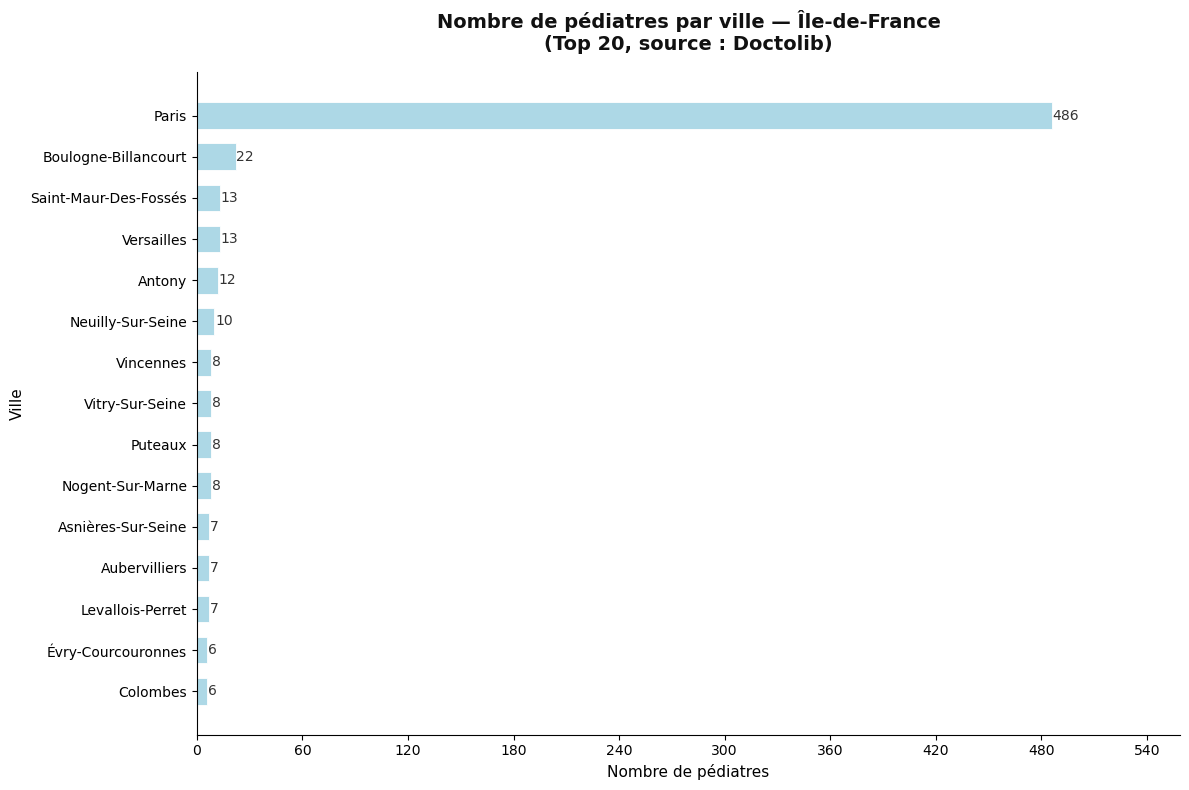

Histogramme sauvegardé : histogramme_pediatres_idf.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Chargement des données
df = pd.read_csv("pédiatres-iledefrance.csv")

# 2. Extraction de la ville depuis l'adresse

def extraire_ville(adresse):
    if pd.isna(adresse):
        return "Inconnue"
    match = re.search(r'\b\d{5}\b\s+([A-Za-zÀ-ÿ\s\-]+)', str(adresse))
    if match:
        return match.group(1).strip().title()
    return "Inconnue"

df["ville"] = df["adresse"].apply(extraire_ville)

# 3. Comptage par ville
comptage = (
    df["ville"]
    .value_counts()
    .drop(labels=["Inconnue"], errors="ignore")  # on exclut les non-identifiées
    .head(15)                                     # top 15 villes
    .sort_values(ascending=True)                  # pour affichage horizontal lisible
)

# 4. Tracé de l'histogramme
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    comptage.index,
    comptage.values,
    color="lightblue",
    edgecolor="white",
    linewidth=0.6,
    height=0.65
)

# Valeurs affichées en bout de barre
for bar, val in zip(bars, comptage.values):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        ha="left",
        fontsize=10,
        color="#333333"
    )

# Mise en forme
ax.set_title(
    "Nombre de pédiatres par ville — Île-de-France\n(Top 20, source : Doctolib)",
    fontsize=14,
    fontweight="bold",
    pad=16,
    color="#111111"
)
ax.set_xlabel("Nombre de pédiatres", fontsize=11)
ax.set_ylabel("Ville", fontsize=11)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=10)
ax.set_xlim(0, comptage.values.max() * 1.15)

plt.tight_layout()
plt.savefig("histogramme_pediatres_idf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Histogramme sauvegardé : histogramme_pediatres_idf.png")